In [1]:
import os
import sys
from os import path
sys.path.append(os.path.expanduser('~/albatros_analysis'))
import numpy as np 
import numba as nb
import time
from scipy import linalg
from scipy import stats
from matplotlib import pyplot as plt
from datetime import datetime as dt
from src.correlations import baseband_data_classes as bdc
from src.utils import baseband_utils as butils
from src.utils import orbcomm_utils as outils
import json
import argparse
from scipy.optimize import least_squares
import coord_helper as ch
import h5py
import skyfield.api as sf
import importlib
from numpy.linalg import inv
import numbers

BDC is using numpy


In [5]:
working_directory = '/project/s/sievers/thomasb/mars_data_24'
bits = 1

a2_coords = [79.41721666666666, -90.75885, 176]

In [6]:
importlib.reload(ch)

<module 'coord_helper' from '/home/s/sievers/thomasb/albatros_analysis/scripts/orbcomm/fitting/coord_helper.py'>

In [11]:
solid = []
joint = []
split1 = []
split2 = []

with open(f"{working_directory}/{bits}bit/coords_v3.json", "r") as f:
    data = json.load(f)

    for day, baseline_info in data.items():
        for bline, fits in baseline_info.items():
            solid.append(
                (day, fits['solid'][:3])
            )
            joint.append(
                (day, fits['joint'][:3])
            )


In [8]:
print(solid)

[('07_11', [79.41722673344327, -90.75879303201614, 181.79756445406477]), ('08_11', [79.4172121612181, -90.75879416289766, 182.957098047586]), ('09_11', [79.41721762793186, -90.75891970930427, 182.21856116695858]), ('10_11', [79.41722013642, -90.75889542919207, 183.07434109956927])]


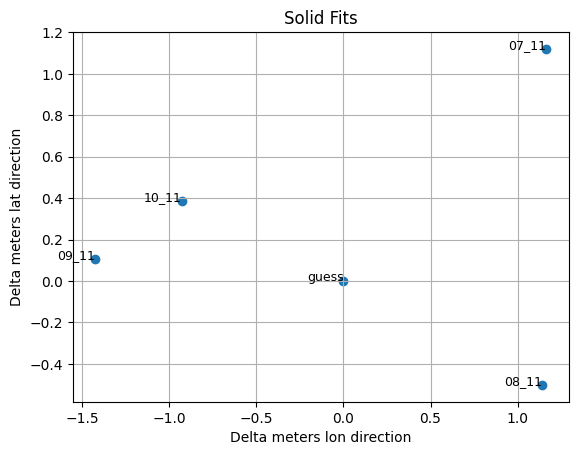

In [12]:
solid = ch.make_coord_plot(a2_coords, solid, 'Solid Fits')

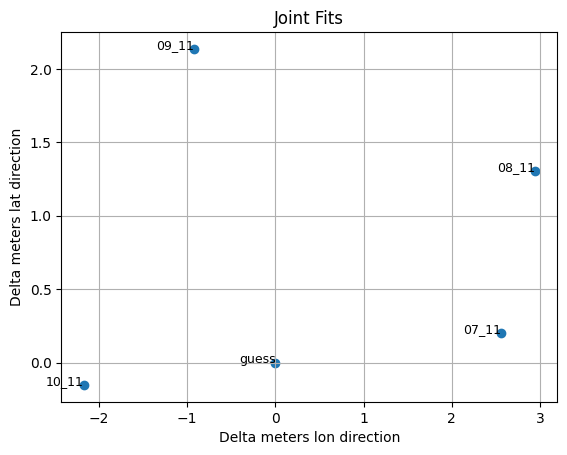

In [13]:
per = ch.make_coord_plot(a2_coords, joint, 'Joint Fits')

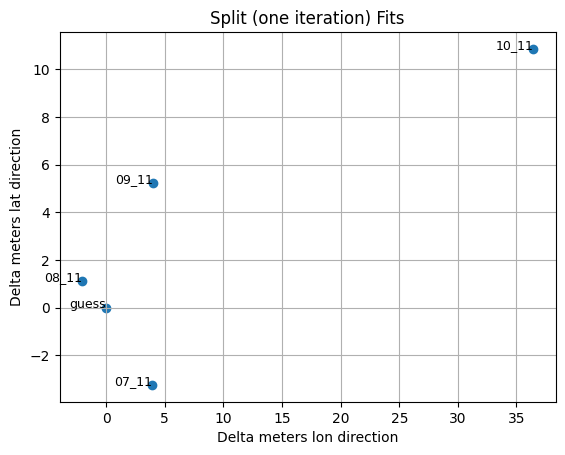

In [8]:
per = ch.make_coord_plot(a2_coords, split1, 'Split (one iteration) Fits')

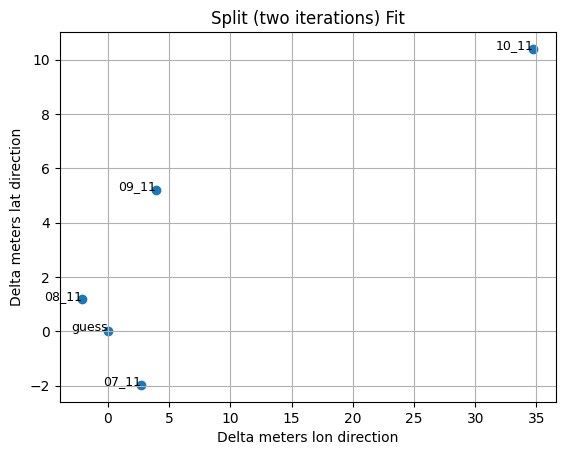

In [9]:
per = ch.make_coord_plot(a2_coords, split2, 'Split (two iterations) Fit')

In [29]:
cov = []
with open(f"{working_directory}/{bits}bit/coordinates.json", "r") as f:
    data = json.load(f)

    for day, baseline_info in data.items():
        for bline, fits in baseline_info.items():
            cov.append(
                (day, fits['cov'][:3])
            )

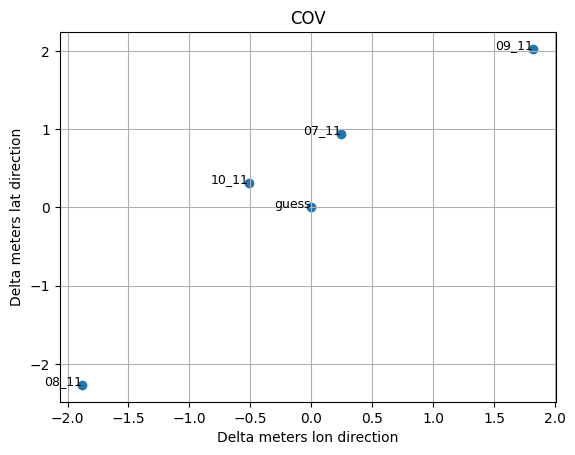

In [30]:
per = ch.make_coord_plot(a2_coords, cov, 'COV')

In [23]:
with open(f"{working_directory}/{bits}bit/coords_v2.json", "r") as f:
    data = json.load(f)
    one = data['07_11']['bline1']["solid"]
    two = data['07_11']['bline1']['sanity_check']